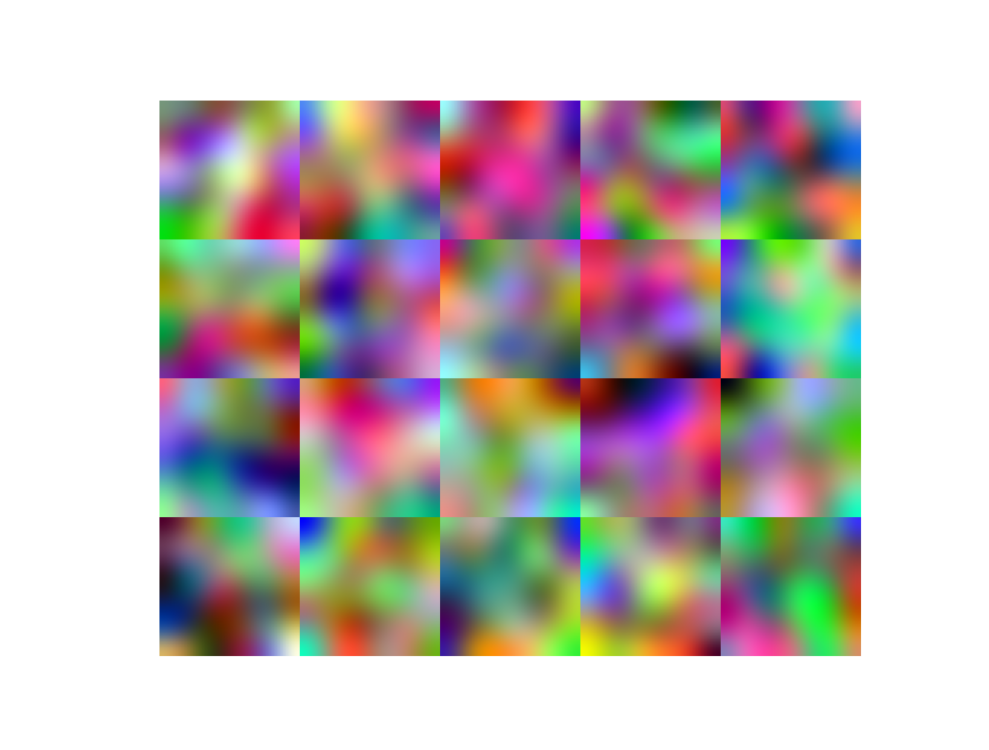

In [8]:
import sys
sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from src.process_images import load_pre_target

_, target = load_pre_target(
    pre_path="../data/siren-examples_best.png",
    target_path="../data/examples_best.png",
    rows=4, cols=5, top=60, bottom=55, left=98, right=78
)

def perlin_like(shape, scale=12, seed=0):
    rng = np.random.default_rng(seed)
    n = gaussian_filter(rng.random(shape[:2]), sigma=scale)
    return ((n - n.min()) / (n.max() - n.min()) * 255).astype(np.uint8)

ss = 11
noisy = np.stack([
    np.stack([perlin_like(target[k].shape, seed=k*3+c + ss) for c in range(3)], axis=-1)
    for k in range(len(target))
])

# Assemble into one grid image
th, tw = target[0].shape[:2]
grid = np.concatenate([
    np.concatenate([noisy[r*5+c] for c in range(5)], axis=1)
    for r in range(4)
], axis=0)

# Add white border matching the original crop amounts
border = (60, 55, 98, 78)  # top, bottom, left, right
h, w = grid.shape[:2]
canvas = np.full((h + border[0] + border[1], w + border[2] + border[3], 3), 255, dtype=np.uint8)
canvas[border[0]:border[0]+h, border[2]:border[2]+w] = grid

plt.figure(figsize=(10, 8))
plt.imshow(canvas)
plt.axis("off")
plt.tight_layout()
plt.show()